# Titanic Baseline → SMOTE 실험

기존 `titanic_1` Baseline에서 **SMOTE만 추가**해 효과를 비교하는 실험입니다.

## 가설
- `survived=1` 클래스가 상대적으로 적기 때문에, 학습 데이터에 SMOTE를 적용하면 생존 클래스 학습이 개선될 수 있다.
- 기존 Baseline Feature, 데이터 분리 방식, CatBoost 설정은 그대로 유지한다.
- 범주형 데이터는 먼저 One-Hot Encoding으로 수치화한 뒤 SMOTE를 적용한다.
- **SMOTE는 Train에만 적용하고 Validation에는 절대 적용하지 않는다.**

## 비교 지표
- Train AUC
- Validation AUC
- Train-Validation Gap
- Accuracy / Precision / Recall / F1
- Confusion Matrix (TN / FP / FN / TP)

## 0. 필요한 패키지
`imbalanced-learn`이 없다면 아래 주석을 풀고 한 번만 실행하세요.

In [3]:
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


## 1. Import & 데이터 불러오기

In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

from common.utils import train_test_split_by_target
from common.interaction_experiments import FeaturePreprocessor, fit_cat, baseline_parameters

train = pd.read_csv('csv/train.csv')
test = pd.read_csv('csv/test.csv')

print('train:', train.shape)
print('test :', test.shape)
display(train.head())

train: (916, 12)
test : (393, 11)


,passengerid,survived,pclass,name,gender,age,sibsp,parch,ticket,fare,cabin,embarked
0,0,0,2,"Wheeler, Mr. Edwin Frederick""""",male,NaN,0,0,SC/PARIS 2159,12.8750,NaN,S
1,1,0,3,"Henry, Miss. Delia",female,NaN,0,0,382649,7.7500,NaN,Q
2,2,1,1,"Hays, Mrs. Charles Melville (Clara Jennings Gr...",female,52.0,1,1,12749,93.5000,B69,S
3,3,1,3,"Andersson, Mr. August Edvard (""Wennerstrom"")",male,27.0,0,0,350043,7.7958,NaN,S
4,4,0,2,"Hold, Mr. Stephen",male,44.0,1,0,26707,26.0000,NaN,S


## 2. Target 정의 & Train / Validation 분리
기존 Baseline과 동일하게 `train_test_split_by_target()`을 사용합니다.

In [5]:
target_col = 'survived'
id_col = 'passengerid'

X = train.drop(columns=[target_col, id_col])
y = train[target_col]

train_part, valid_part = train_test_split_by_target(
    train,
    target_name=target_col
)

X_tr_raw = train_part.drop(columns=[target_col, id_col])
y_tr = train_part[target_col]

X_valid_raw = valid_part.drop(columns=[target_col, id_col])
y_valid = valid_part[target_col]

print('전체 Target 비율')
print(y.value_counts())
print(y.value_counts(normalize=True))

print()
print('Train Target 비율')
print(y_tr.value_counts())
print(y_tr.value_counts(normalize=True))

print()
print('Train / Validation shape')
print(X_tr_raw.shape, X_valid_raw.shape)

전체 Target 비율
survived
0    570
1    346
Name: count, dtype: int64
survived
0    0.622271
1    0.377729
Name: proportion, dtype: float64

Train Target 비율
survived
0    427
1    260
Name: count, dtype: int64
survived
0    0.621543
1    0.378457
Name: proportion, dtype: float64

Train / Validation shape
(687, 10) (229, 10)


## 3. Baseline 전처리
`titanic_1`과 동일하게 `FeaturePreprocessor()`를 사용합니다. 추가 interaction feature는 넣지 않습니다.

In [6]:
baseline_prep = FeaturePreprocessor()

# 1) 결측치 처리 규칙은 Train에서만 학습
baseline_prep.fit_missing(X_tr_raw)
X_tr_clean = baseline_prep.transform_missing(X_tr_raw)
X_valid_clean = baseline_prep.transform_missing(X_valid_raw)

assert not X_tr_clean.isna().any().any()
assert not X_valid_clean.isna().any().any()

# 2) Baseline 파생 피처 생성: FamilySize / IsAlone
X_tr_features = baseline_prep.feature_frame(X_tr_raw, X_tr_clean)
X_valid_features = baseline_prep.feature_frame(X_valid_raw, X_valid_clean)

print('인코딩 전 Baseline Feature')
print(X_tr_features.columns.tolist())
display(X_tr_features.head())

인코딩 전 Baseline Feature
['pclass', 'gender', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'FamilySize', 'IsAlone']


,pclass,gender,age,sibsp,parch,fare,embarked,FamilySize,IsAlone
595,3,male,0.83,0,1,9.3500,S,2,0
148,3,male,24.00,0,0,8.0500,S,1,1
347,3,female,9.00,1,1,15.2458,C,3,0
731,3,female,24.00,0,2,16.7000,S,3,0
457,2,male,44.00,0,0,13.0000,S,1,1


## 4. One-Hot Encoding
SMOTE는 수치형 입력을 사용하므로 범주형 피처를 먼저 인코딩합니다.

**중요:** Encoder는 Train에만 `fit`, Validation에는 `transform`만 합니다.

In [7]:
baseline_prep.fit_encoding(X_tr_features)

X_tr_model = baseline_prep.transform_encoding(X_tr_features)
X_valid_model = baseline_prep.transform_encoding(X_valid_features)

assert X_tr_model.columns.equals(X_valid_model.columns)

print('Encoding 후 shape')
print('Train     :', X_tr_model.shape)
print('Validation:', X_valid_model.shape)

print()
print('Encoding 후 dtype')
display(X_tr_model.dtypes.to_frame('dtype'))

Encoding 후 shape
Train     : (687, 12)
Validation: (229, 12)

Encoding 후 dtype


,dtype
pclass,float64
age,float64
sibsp,float64
parch,float64
fare,float64
FamilySize,float64
IsAlone,float64
gender_female,float64
gender_male,float64
embarked_C,float64


## 5. SMOTE 적용 전 수치형 여부 확인

In [8]:
non_numeric_cols = X_tr_model.select_dtypes(exclude='number').columns.tolist()

print('비수치형 컬럼:', non_numeric_cols)

assert len(non_numeric_cols) == 0, (
    f'SMOTE 적용 전 비수치형 컬럼이 남아 있습니다: {non_numeric_cols}'
)

assert np.isfinite(X_tr_model.to_numpy()).all()
assert np.isfinite(X_valid_model.to_numpy()).all()

print('모든 모델 입력이 수치형이며 NaN/inf가 없습니다.')

비수치형 컬럼: []
모든 모델 입력이 수치형이며 NaN/inf가 없습니다.


## 6. 원본 Baseline 학습
SMOTE 적용 전 모델을 먼저 학습해서 같은 Validation set에서 비교 기준을 만듭니다.

In [9]:
baseline_model = fit_cat(X_tr_model, y_tr)

print('Baseline 명시적 설정')
print(baseline_parameters())

Baseline 명시적 설정
{'verbose': 0, 'random_state': 42, 'cat_features': [], 'allow_writing_files': False}


## 7. Baseline AUC 계산

In [10]:
def positive_proba(model, X):
    positive_index = list(model.classes_).index(1)
    return model.predict_proba(X)[:, positive_index]

baseline_train_proba = positive_proba(baseline_model, X_tr_model)
baseline_valid_proba = positive_proba(baseline_model, X_valid_model)

baseline_train_auc = roc_auc_score(y_tr, baseline_train_proba)
baseline_valid_auc = roc_auc_score(y_valid, baseline_valid_proba)
baseline_gap = baseline_train_auc - baseline_valid_auc

print('===== Original Baseline =====')
print(f'Train AUC      : {baseline_train_auc:.6f}')
print(f'Validation AUC : {baseline_valid_auc:.6f}')
print(f'Gap            : {baseline_gap:.6f}')

===== Original Baseline =====
Train AUC      : 0.963079
Validation AUC : 0.900065
Gap            : 0.063014


## 8. Train 데이터에만 SMOTE 적용
Validation 데이터에는 SMOTE를 적용하지 않습니다.

In [11]:
smote = SMOTE(random_state=42)

print('===== SMOTE 적용 전 =====')
print(y_tr.value_counts().sort_index())

X_tr_smote, y_tr_smote = smote.fit_resample(
    X_tr_model,
    y_tr
)

# imbalanced-learn 버전에 따라 ndarray로 반환될 경우를 대비
if not isinstance(X_tr_smote, pd.DataFrame):
    X_tr_smote = pd.DataFrame(
        X_tr_smote,
        columns=X_tr_model.columns
    )

if not isinstance(y_tr_smote, pd.Series):
    y_tr_smote = pd.Series(
        y_tr_smote,
        name=y_tr.name
    )

print()
print('===== SMOTE 적용 후 =====')
print(y_tr_smote.value_counts().sort_index())

print()
print('Train shape')
print(X_tr_model.shape, '→', X_tr_smote.shape)

===== SMOTE 적용 전 =====
survived
0    427
1    260
Name: count, dtype: int64

===== SMOTE 적용 후 =====
survived
0    427
1    427
Name: count, dtype: int64

Train shape
(687, 12) → (854, 12)


## 9. SMOTE 모델 학습
CatBoost 설정은 Baseline과 동일하고, 학습 데이터만 SMOTE 결과를 사용합니다.

In [12]:
smote_model = fit_cat(
    X_tr_smote,
    y_tr_smote
)

print('Baseline / SMOTE 모델 파라미터 동일 여부:')
print(smote_model.get_all_params() == baseline_model.get_all_params())

Baseline / SMOTE 모델 파라미터 동일 여부:
False


## 10. SMOTE 모델 AUC 평가
Train AUC도 **원본 Train 데이터**로 평가합니다. SMOTE로 만든 synthetic sample에서 평가하지 않습니다.

In [13]:
smote_train_proba = positive_proba(smote_model, X_tr_model)
smote_valid_proba = positive_proba(smote_model, X_valid_model)

smote_train_auc = roc_auc_score(y_tr, smote_train_proba)
smote_valid_auc = roc_auc_score(y_valid, smote_valid_proba)
smote_gap = smote_train_auc - smote_valid_auc

print('===== SMOTE Model =====')
print(f'Train AUC      : {smote_train_auc:.6f}')
print(f'Validation AUC : {smote_valid_auc:.6f}')
print(f'Gap            : {smote_gap:.6f}')

===== SMOTE Model =====
Train AUC      : 0.967727
Validation AUC : 0.900146
Gap            : 0.067580


## 11. AUC 비교표

In [14]:
auc_comparison = pd.DataFrame(
    {
        'Baseline': [
            baseline_train_auc,
            baseline_valid_auc,
            baseline_gap
        ],
        'SMOTE': [
            smote_train_auc,
            smote_valid_auc,
            smote_gap
        ]
    },
    index=[
        'Train AUC',
        'Validation AUC',
        'Gap'
    ]
)

auc_comparison['Difference'] = (
    auc_comparison['SMOTE']
    - auc_comparison['Baseline']
)

display(auc_comparison)

,Baseline,SMOTE,Difference
Train AUC,0.963079,0.967727,0.004648
Validation AUC,0.900065,0.900146,0.000081
Gap,0.063014,0.067580,0.004566


## 12. Threshold 0.5 기준 예측
AUC는 확률 순위를 평가하지만 Confusion Matrix는 0/1 예측이 필요하므로 기본 threshold `0.5`를 사용합니다.

In [15]:
threshold = 0.5

baseline_valid_pred = (
    baseline_valid_proba >= threshold
).astype(int)

smote_valid_pred = (
    smote_valid_proba >= threshold
).astype(int)

## 13. Baseline vs SMOTE Confusion Matrix

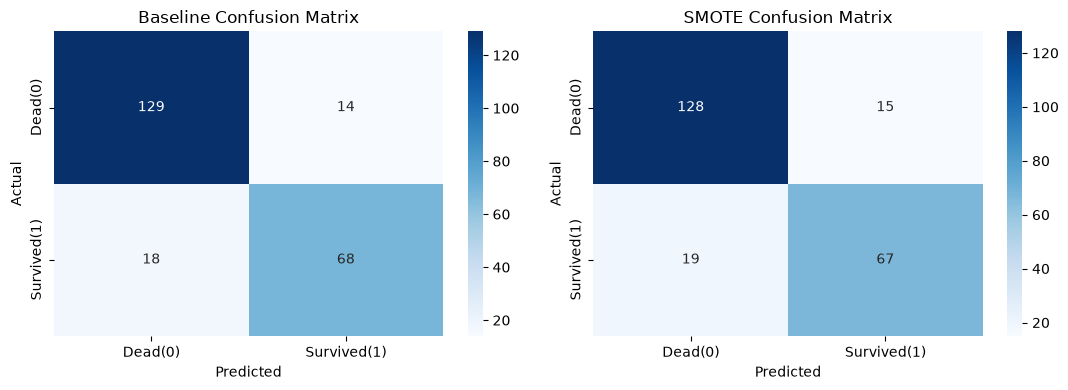

In [16]:
baseline_cm = confusion_matrix(
    y_valid,
    baseline_valid_pred
)

smote_cm = confusion_matrix(
    y_valid,
    smote_valid_pred
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.heatmap(
    baseline_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Dead(0)', 'Survived(1)'],
    yticklabels=['Dead(0)', 'Survived(1)'],
    ax=axes[0]
)
axes[0].set_title('Baseline Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(
    smote_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Dead(0)', 'Survived(1)'],
    yticklabels=['Dead(0)', 'Survived(1)'],
    ax=axes[1]
)
axes[1].set_title('SMOTE Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## 14. Accuracy / Precision / Recall / F1 비교

In [17]:
def classification_scores(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
    }

baseline_cls = classification_scores(
    y_valid,
    baseline_valid_pred
)

smote_cls = classification_scores(
    y_valid,
    smote_valid_pred
)

classification_comparison = pd.DataFrame({
    'Baseline': baseline_cls,
    'SMOTE': smote_cls
})

classification_comparison['Difference'] = (
    classification_comparison['SMOTE']
    - classification_comparison['Baseline']
)

display(classification_comparison)

,Baseline,SMOTE,Difference
Accuracy,0.860262,0.851528,-0.008734
Precision,0.829268,0.817073,-0.012195
Recall,0.790698,0.779070,-0.011628
F1,0.809524,0.797619,-0.011905


## 15. TN / FP / FN / TP 비교

In [18]:
baseline_tn, baseline_fp, baseline_fn, baseline_tp = baseline_cm.ravel()
smote_tn, smote_fp, smote_fn, smote_tp = smote_cm.ravel()

cm_comparison = pd.DataFrame(
    {
        'Baseline': [
            baseline_tn,
            baseline_fp,
            baseline_fn,
            baseline_tp
        ],
        'SMOTE': [
            smote_tn,
            smote_fp,
            smote_fn,
            smote_tp
        ]
    },
    index=['TN', 'FP', 'FN', 'TP']
)

cm_comparison['Difference'] = (
    cm_comparison['SMOTE']
    - cm_comparison['Baseline']
)

display(cm_comparison)

,Baseline,SMOTE,Difference
TN,129,128,-1
FP,14,15,1
FN,18,19,1
TP,68,67,-1


## 16. Classification Report

In [19]:
print('===== Baseline =====')
print(classification_report(
    y_valid,
    baseline_valid_pred,
    digits=4
))

print('===== SMOTE =====')
print(classification_report(
    y_valid,
    smote_valid_pred,
    digits=4
))

===== Baseline =====
              precision    recall  f1-score   support

           0     0.8776    0.9021    0.8897       143
           1     0.8293    0.7907    0.8095        86

    accuracy                         0.8603       229
   macro avg     0.8534    0.8464    0.8496       229
weighted avg     0.8594    0.8603    0.8596       229

===== SMOTE =====
              precision    recall  f1-score   support

           0     0.8707    0.8951    0.8828       143
           1     0.8171    0.7791    0.7976        86

    accuracy                         0.8515       229
   macro avg     0.8439    0.8371    0.8402       229
weighted avg     0.8506    0.8515    0.8508       229



## 17. 최종 요약

In [20]:
print('=' * 55)
print('SMOTE 실험 결과 요약')
print('=' * 55)

print(
    f'Validation AUC : '
    f'{baseline_valid_auc:.6f} → {smote_valid_auc:.6f} '
    f'({smote_valid_auc - baseline_valid_auc:+.6f})'
)

print(
    f'Accuracy       : '
    f"{baseline_cls['Accuracy']:.6f} → {smote_cls['Accuracy']:.6f} "
    f"({smote_cls['Accuracy'] - baseline_cls['Accuracy']:+.6f})"
)

print(
    f'Recall         : '
    f"{baseline_cls['Recall']:.6f} → {smote_cls['Recall']:.6f} "
    f"({smote_cls['Recall'] - baseline_cls['Recall']:+.6f})"
)

print(
    f'F1             : '
    f"{baseline_cls['F1']:.6f} → {smote_cls['F1']:.6f} "
    f"({smote_cls['F1'] - baseline_cls['F1']:+.6f})"
)

print()
print(f'FP : {baseline_fp} → {smote_fp} ({smote_fp - baseline_fp:+d})')
print(f'FN : {baseline_fn} → {smote_fn} ({smote_fn - baseline_fn:+d})')

print()
if smote_valid_auc > baseline_valid_auc:
    print('AUC 기준: SMOTE가 개선되었습니다.')
else:
    print('AUC 기준: SMOTE가 개선되지 않았습니다.')

if smote_fn < baseline_fn:
    print('FN 기준: 생존자를 놓치는 경우가 감소했습니다.')
elif smote_fn > baseline_fn:
    print('FN 기준: 생존자를 놓치는 경우가 증가했습니다.')
else:
    print('FN 기준: 변화가 없습니다.')

if smote_fp > baseline_fp:
    print('FP 기준: 사망자를 생존으로 잘못 예측하는 경우가 증가했습니다.')
elif smote_fp < baseline_fp:
    print('FP 기준: 사망자를 생존으로 잘못 예측하는 경우가 감소했습니다.')
else:
    print('FP 기준: 변화가 없습니다.')

SMOTE 실험 결과 요약
Validation AUC : 0.900065 → 0.900146 (+0.000081)
Accuracy       : 0.860262 → 0.851528 (-0.008734)
Recall         : 0.790698 → 0.779070 (-0.011628)
F1             : 0.809524 → 0.797619 (-0.011905)

FP : 14 → 15 (+1)
FN : 18 → 19 (+1)

AUC 기준: SMOTE가 개선되었습니다.
FN 기준: 생존자를 놓치는 경우가 증가했습니다.
FP 기준: 사망자를 생존으로 잘못 예측하는 경우가 증가했습니다.


## 해석할 때 주의할 점

이번 실험은 요청대로 **One-Hot Encoding → 일반 SMOTE** 순서입니다. 따라서 SMOTE가 synthetic sample을 만들 때 one-hot 컬럼에 `0.3`, `0.7` 같은 중간값이 생길 수 있습니다.

따라서 이번 결과가 좋아도 바로 최종 채택하기보다는 다음 단계에서 `SMOTENC`와 비교하는 것이 더 엄밀합니다.

이번 실험의 핵심 질문은 하나입니다.

> **Baseline에서 SMOTE 하나만 추가했을 때 Validation AUC와 혼동행렬이 실제로 개선되는가?**

In [ ]:
X_test_model = final_prep.transform(X_test_raw)
assert X_test_model.columns.equals(X_full_model.columns)
positive_index = list(submission_model.classes_).index(1)
predictions = submission_model.predict_proba(X_test_model)[:, positive_index]
assert np.isfinite(predictions).all()
assert ((predictions>=0)&(predictions<=1)).all()

In [21]:
output_path = Path('submission/titanic_result_16.csv')
assert not output_path.exists(), '기존 결과를 덮어쓰지 않습니다.'
assert submission.columns.tolist()==[id_col,target_col]
assert len(submission)==len(test)
assert submission[id_col].is_unique and submission[id_col].notna().all()
assert set(submission[id_col])==set(test[id_col])
result = submission.copy(deep=True)
by_id = pd.Series(predictions,index=test[id_col].to_numpy())
result[target_col] = result[id_col].map(by_id)
assert result[target_col].notna().all()
result.to_csv(output_path,index=False)
saved = pd.read_csv(output_path)
assert saved.shape==submission.shape==(len(test),2)
assert saved.columns.equals(submission.columns)
pd.testing.assert_frame_equal(saved.drop(columns=target_col),submission.drop(columns=target_col))
assert pd.api.types.is_float_dtype(saved[target_col])
assert saved[target_col].notna().all() and saved[target_col].between(0,1).all()
np.testing.assert_allclose(saved[target_col],by_id.loc[submission[id_col]],atol=1e-15,rtol=1e-12)
print('검증 통과:', output_path, saved.shape)

NameError: name 'submission' is not defined